
# **Project 1: Student Performance Predictor**
**Task 1: Load and Explore the Data**
-----------------------------------------------------------
Goal: Build a realistic dataset of "Hours Studied" vs "Exam Score"
for 60 students and explore it (structure, missing values, stats).

Note: This dataset is generated programmatically (not copied from any
textbook/sample). Study hours range from 0.5 to 12 hours, and scores
are generated using a realistic relationship (score grows with hours,
flattens near the top, and has natural random variation between
students) so the data resembles real exam results.

The cleaned dataset is saved to 'student_data.csv' so Task 2 and
Task 3 can reuse the exact same data.

In [1]:
import numpy as np
import pandas as pd

In [2]:
# ---------------------------------------------------------
# Step 1: Generate an original dataset of 60 students
# ---------------------------------------------------------
np.random.seed(42)  # for reproducibility

n_students = 60
student_ids = [f"S{str(i).zfill(3)}" for i in range(1, n_students + 1)]

# Hours studied: random values between 0.5 and 12 hours
hours_studied = np.round(np.random.uniform(0.5, 12, n_students), 1)

# Exam score: base relationship + diminishing returns + random noise
# (more hours generally means a higher score, but it tapers off near 100
#  and every student has some natural variation)
base_score = 30 + (hours_studied * 6.2) - (hours_studied ** 2) * 0.15
noise = np.random.normal(loc=0, scale=4, size=n_students)
exam_score = base_score + noise

# Clip scores so they stay within a realistic 0-100 range
exam_score = np.clip(exam_score, 0, 100)
exam_score = np.round(exam_score, 1)

df = pd.DataFrame({
    "StudentID": student_ids,
    "HoursStudied": hours_studied,
    "ExamScore": exam_score
})

# Intentionally introduce a couple of missing values, like real-world data
df.loc[5, "ExamScore"] = np.nan
df.loc[22, "HoursStudied"] = np.nan

In [3]:
# ---------------------------------------------------------
# Step 2: Explore the data
# ---------------------------------------------------------
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset shape (rows, columns):", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

First 5 rows:
  StudentID  HoursStudied  ExamScore
0      S001           4.8       50.4
1      S002          11.4       78.3
2      S003           8.9       71.5
3      S004           7.4       71.9
4      S005           2.3       44.8

Last 5 rows:
   StudentID  HoursStudied  ExamScore
55      S056          11.1       79.4
56      S057           1.5       33.3
57      S058           2.8       44.5
58      S059           1.0       34.7
59      S060           4.2       50.2

Dataset shape (rows, columns): (60, 3)

Column data types:
StudentID        object
HoursStudied    float64
ExamScore       float64
dtype: object

Missing values per column:
StudentID       0
HoursStudied    1
ExamScore       1
dtype: int64

Summary statistics:
       HoursStudied  ExamScore
count     59.000000  59.000000
mean       5.908475  59.464407
std        3.538327  15.041755
min        0.700000  33.300000
25%        2.600000  47.100000
50%        5.700000  59.800000
75%        8.750000  72.150000
max       11

In [4]:
# ---------------------------------------------------------
# Step 3: Clean the data (handle missing values)
# ---------------------------------------------------------
# Fill missing HoursStudied / ExamScore with the column median
df["HoursStudied"] = df["HoursStudied"].fillna(df["HoursStudied"].median())
df["ExamScore"] = df["ExamScore"].fillna(df["ExamScore"].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
StudentID       0
HoursStudied    0
ExamScore       0
dtype: int64


In [5]:
# ---------------------------------------------------------
# Step 4: Save the cleaned dataset for Task 2
# ---------------------------------------------------------
output_path = "student_data.csv"
df.to_csv(output_path, index=False)
print(f"\nCleaned dataset with {len(df)} students saved to '{output_path}'.")
print("This file will be used by Task 2 to train the model.")


Cleaned dataset with 60 students saved to 'student_data.csv'.
This file will be used by Task 2 to train the model.


**Task 2: Train a Linear Regression Model**
-----------------------------------------------------------
Goal: Load the dataset created in Task 1, split it into training
and testing sets, and train a linear regression model that learns
the relationship between hours studied and exam score.

Requires: 'student_data.csv' (created by task1_load_explore_data.py)
must be in the same folder.

This script saves the trained model to 'exam_score_model.pkl' so
Task 3 can load it and run evaluation/predictions without retraining.


In [6]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [7]:
# ---------------------------------------------------------
# Step 1: Load the dataset produced by Task 1
# ---------------------------------------------------------
df = pd.read_csv("student_data.csv")
print(f"Loaded {len(df)} student records from 'student_data.csv'.")
print(df.head())

Loaded 60 student records from 'student_data.csv'.
  StudentID  HoursStudied  ExamScore
0      S001           4.8       50.4
1      S002          11.4       78.3
2      S003           8.9       71.5
3      S004           7.4       71.9
4      S005           2.3       44.8


In [8]:
# ---------------------------------------------------------
# Step 2: Define features (X) and target (y)
# ---------------------------------------------------------
X = df[["HoursStudied"]]   # double brackets -> keeps it as a DataFrame
y = df["ExamScore"]

In [9]:
# ---------------------------------------------------------
# Step 3: Split into training (80%) and testing (20%) sets
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {len(X_train)} students")
print(f"Testing set size: {len(X_test)} students")


Training set size: 48 students
Testing set size: 12 students


In [10]:
# ---------------------------------------------------------
# Step 4: Create and train the Linear Regression model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("\nModel trained successfully.")
print(f"Slope (coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"\nInterpretation: each extra hour studied changes the predicted "
      f"score by about {slope:.2f} points. With 0 hours studied, the "
      f"baseline predicted score is about {intercept:.2f}.")


Model trained successfully.
Slope (coefficient): 4.19
Intercept: 34.61

Interpretation: each extra hour studied changes the predicted score by about 4.19 points. With 0 hours studied, the baseline predicted score is about 34.61.


In [11]:
# ---------------------------------------------------------
# Step 5: Save the trained model and the train/test split
#         so Task 3 can evaluate it without retraining
# ---------------------------------------------------------
joblib.dump(model, "exam_score_model.pkl")

X_test.assign(ActualScore=y_test).to_csv("test_set.csv", index=False)
X_train.assign(ActualScore=y_train).to_csv("train_set.csv", index=False)

print("\nModel saved to 'exam_score_model.pkl'.")
print("Test set saved to 'test_set.csv' for use in Task 3.")


Model saved to 'exam_score_model.pkl'.
Test set saved to 'test_set.csv' for use in Task 3.


**Task 3: Evaluate and Make Predictions**
-----------------------------------------------------------
Goal: Load the model trained in Task 2, evaluate it on the test
set using Mean Absolute Error (MAE) and R-squared, compare
predicted vs actual scores, and predict scores for new students.

Also generates a plot showing the full dataset, the regression line,
and the predictions for new students, saved as 'prediction_plot.png'.

Requires: 'exam_score_model.pkl', 'test_set.csv', and 'train_set.csv'
(all created by task2_train_model.py) must be in the same folder.


In [12]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
# ---------------------------------------------------------
# Step 1: Load the trained model and the saved test set
# ---------------------------------------------------------
model = joblib.load("exam_score_model.pkl")
test_df = pd.read_csv("test_set.csv")
train_df = pd.read_csv("train_set.csv")

X_test = test_df[["HoursStudied"]]
y_test = test_df["ActualScore"]

print(f"Loaded trained model and {len(test_df)} test records.")

Loaded trained model and 12 test records.


In [14]:
# ---------------------------------------------------------
# Step 2: Predict on the test data
# ---------------------------------------------------------
y_pred = model.predict(X_test)

In [15]:
# ---------------------------------------------------------
# Step 3: Evaluate performance
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f} points")
print(f"R-squared (R2 score): {r2:.2f}")
print("(Lower MAE is better. R2 closer to 1.0 means the model "
      "explains the data well.)")


Mean Absolute Error (MAE): 3.32 points
R-squared (R2 score): 0.83
(Lower MAE is better. R2 closer to 1.0 means the model explains the data well.)


In [16]:
# ---------------------------------------------------------
# Step 4: Compare actual vs predicted scores on the test set
# ---------------------------------------------------------
results = pd.DataFrame({
    "HoursStudied": test_df["HoursStudied"],
    "ActualScore": y_test.values,
    "PredictedScore": [round(p, 1) for p in y_pred]
})
results["Error"] = (results["ActualScore"] - results["PredictedScore"]).round(1)

print("\nActual vs Predicted scores on test set:")
print(results.to_string(index=False))


Actual vs Predicted scores on test set:
 HoursStudied  ActualScore  PredictedScore  Error
          4.8         50.4            54.7   -4.3
          2.3         59.8            44.3   15.5
          4.0         51.5            51.4    0.1
          8.1         72.4            68.6    3.8
          2.9         45.5            46.8   -1.3
          7.4         67.7            65.6    2.1
         11.4         80.0            82.4   -2.4
          6.8         62.4            63.1   -0.7
         10.1         74.0            76.9   -2.9
          2.8         44.5            46.3   -1.8
          4.1         53.3            51.8    1.5
         11.7         80.4            83.7   -3.3


In [17]:
# ---------------------------------------------------------
# Step 5: Predict exam scores for brand-new students
# ---------------------------------------------------------
new_students = pd.DataFrame({"HoursStudied": [2.5, 4.5, 6.0, 9.5]})
new_predictions = model.predict(new_students)

print("\nPredictions for new students:")
for hours, score in zip(new_students["HoursStudied"], new_predictions):
    print(f"  Studied {hours} hours -> Predicted score: {score:.1f}")

# Save final results for reference
results.to_csv("evaluation_results.csv", index=False)
print("\nEvaluation results saved to 'evaluation_results.csv'.")


Predictions for new students:
  Studied 2.5 hours -> Predicted score: 45.1
  Studied 4.5 hours -> Predicted score: 53.5
  Studied 6.0 hours -> Predicted score: 59.8
  Studied 9.5 hours -> Predicted score: 74.4

Evaluation results saved to 'evaluation_results.csv'.


Plot saved to 'prediction_plot.png'.


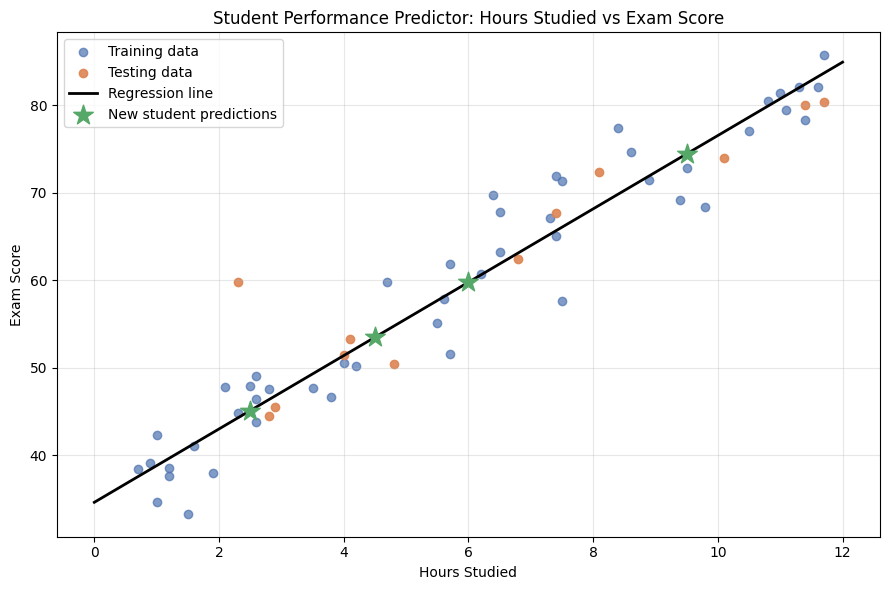

In [18]:
# ---------------------------------------------------------
# Step 6: Plot the data, the regression line, and predictions
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))

# Training points
plt.scatter(train_df["HoursStudied"], train_df["ActualScore"],
            color="#4C72B0", alpha=0.7, label="Training data")

# Testing points
plt.scatter(test_df["HoursStudied"], test_df["ActualScore"],
            color="#DD8452", alpha=0.9, label="Testing data")

# Regression line across the full hours range
hours_range = np.linspace(0, 12, 100).reshape(-1, 1)
score_line = model.predict(pd.DataFrame(hours_range, columns=["HoursStudied"]))
plt.plot(hours_range, score_line, color="black", linewidth=2,
         label="Regression line")

# Highlight predictions for new students
plt.scatter(new_students["HoursStudied"], new_predictions,
            color="#55A868", marker="*", s=220, zorder=5,
            label="New student predictions")

plt.title("Student Performance Predictor: Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plot_path = "prediction_plot.png"
plt.savefig(plot_path, dpi=150)
print(f"Plot saved to '{plot_path}'.")